In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from plotly.subplots import make_subplots
from pathlib import Path
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.model_selection import InstanceHardnessCV
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone

In [ ]:
ds_path = Path("../ml-project/data/raw/dataset_clasification.csv")
data = pd.read_csv(ds_path, sep=",")
pd.set_option("display.max_columns", None)

var_num = data.select_dtypes(include= [np.int64, np.float64]).columns.tolist()
var_cat = data.select_dtypes(include=["object", "string", "category"]).columns.tolist()

target = "Diagnosis"

var_cat.remove(target)
#var_cat.remove("Acne Severity")
var_cat.remove("Country")

data[target] = np.where(
    data["Diagnosis"] == "Yes", 
    1, 
    0
)

data["Acne Severity"] = data["Acne Severity"].fillna("Absent")

X = data.drop(columns=["Diagnosis", "Country"])
y = data["Diagnosis"]

In [4]:
indices_cat = [X.columns.get_loc(col) for col in var_cat]
indices_cat

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,  
    random_state=123,
    stratify=y
)

oversampler = RandomOverSampler(random_state=123)

smote_nc = SMOTENC(
    categorical_features=indices_cat,
    random_state=123,
    sampling_strategy=0.4,
)

# Regresión Logistica

In [6]:
preprocessor_logistic_regression = ColumnTransformer([

    (
        "cat",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ),
        var_cat
    ),

    (
        "num",
        StandardScaler(),
        var_num
    )

])

## Test

In [7]:
clr = LogisticRegression(
    max_iter=1000,
    random_state=123,
    #class_weight="balanced",  # <-- AGREGA ESTA LÍNEA AQUÍ
)

pipeline_logit = ImbPipeline(
    [
        ("preprocessing", preprocessor_logistic_regression), 
        ("oversampling", oversampler), 
        ("model", clr)
    ]
)

pipeline_logit.fit(X_train, y_train)

y_pred = pipeline_logit.predict(X_test)
y_prob = pipeline_logit.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

MÉTRICAS DEL MODELO
Accuracy : 0.5162
Precision: 0.1041
Recall   : 0.4746
F1-Score : 0.1707
ROC-AUC  : 0.5008


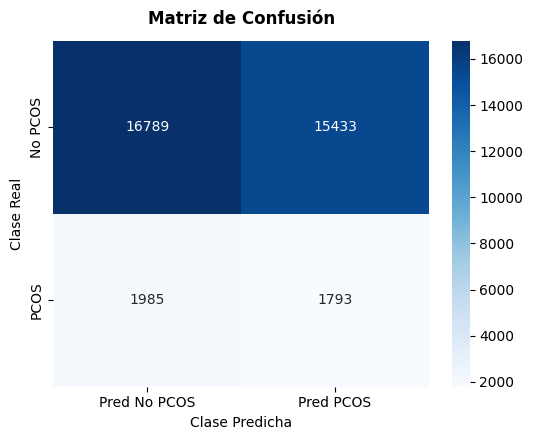



REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

     No PCOS       0.89      0.52      0.66     32222
        PCOS       0.10      0.47      0.17      3778

    accuracy                           0.52     36000
   macro avg       0.50      0.50      0.41     36000
weighted avg       0.81      0.52      0.61     36000



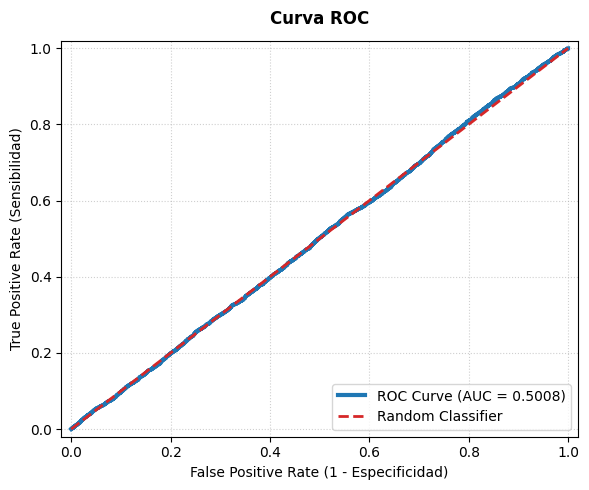

In [ ]:
# PRINT DE RESULTADOS EN CONSOLA
print("="*19)
print("MÉTRICAS DEL MODELO")
print("="*19)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
# El F1 ya no será cero gracias al class_weight='balanced'
print(f"F1-Score : {f1:.4f}") 
print(f"ROC-AUC  : {auc:.4f}")

# ============================================= #
# 2. GRÁFICA 1: MATRIZ DE CONFUSIÓN (SEABORN)   #
# ============================================= #
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
# El formato "d" es para que muestre los números enteros completos sin decimales
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Pred No PCOS", "Pred PCOS"],
            yticklabels=["No PCOS", "PCOS"])

plt.title("Matriz de Confusión", fontsize=12, fontweight='bold', pad=12)
plt.ylabel("Clase Real", fontsize=10)
plt.xlabel("Clase Predicha", fontsize=10)
plt.tight_layout()
plt.show()

# ============================================= #
# 3. PRINT DEL REPORTE DE CLASIFICACIÓN        #
# ============================================= #
print("\n")
print("="*24)
print("REPORTE DE CLASIFICACIÓN")
print("="*24)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No PCOS", "PCOS"]
    )
)

# ============================================= #
# 4. GRÁFICA 2: CURVA ROC (MATPLOTLIB)          #
# ============================================= #
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
# Pintamos la curva del modelo en azul
plt.plot(fpr, tpr, color="#1f77b4", lw=3, label=f"ROC Curve (AUC = {auc:.4f})")
# Pintamos la línea diagonal segmentada del clasificador aleatorio en rojo
plt.plot([0, 1], [0, 1], color="#d62728", linestyle="--", lw=2, label="Random Classifier")

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)", fontsize=10)
plt.ylabel("True Positive Rate (Sensibilidad)", fontsize=10)
plt.title("Curva ROC", fontsize=12, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## CV

In [9]:
cv = InstanceHardnessCV(
    estimator=pipeline_logit, 
    n_splits=5, 
)

metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    estimator=pipeline_logit,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=metrics,
    return_train_score=False,
    n_jobs=-1
)

results_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Promedio": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],

    "Desv. Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

results_df

,Métrica,Promedio,Desv. Std
0,Accuracy,0.509167,0.006421
1,Precision,0.105515,0.001628
2,Recall,0.491552,0.005255
3,F1-Score,0.173732,0.002396
4,ROC-AUC,0.502663,0.004224


## Hiperparametros

In [22]:
param_dist = {

    # Regularización
    "model__C": uniform(0.001, 20),

    # Tipo de penalización
    "model__penalty": ["l1", "l2"],

    # Solver compatible
    "model__solver": ["liblinear", "saga"],

    # Balanceo automático
    #"model__class_weight": [
    #    "balanced"
    #]
}

# ================= #
# RANDOM SEARCH #
# ================= #

random_search = RandomizedSearchCV(
    estimator=pipeline_logit,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=123,
    n_jobs=-1
)

# ================= #
# 23. ENTRENAMIENTO #
# ================= #

random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': <scipy.stats....x7f5ed9257350>, 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [23]:
best_model = random_search.best_estimator_

print("\n")
print("="*23)
print("MEJORES HIPERPARÁMETROS")
print("="*23)

print(random_search.best_params_)
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
auc = roc_auc_score(y_test, y_prob_best)

results_final = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

results_final["Valor"] = (
    results_final["Valor"]
    .round(4)
)

print("\n")
print("="*18)
print("RESULTADOS FINALES")
print("="*18)
print(results_final)



MEJORES HIPERPARÁMETROS
{'model__C': np.float64(1.8430987989015035), 'model__penalty': 'l1', 'model__solver': 'saga'}


RESULTADOS FINALES
     Métrica   Valor
0   Accuracy  0.5176
1  Precision  0.1053
2     Recall  0.4796
3   F1-Score  0.1726
4    ROC-AUC  0.5006


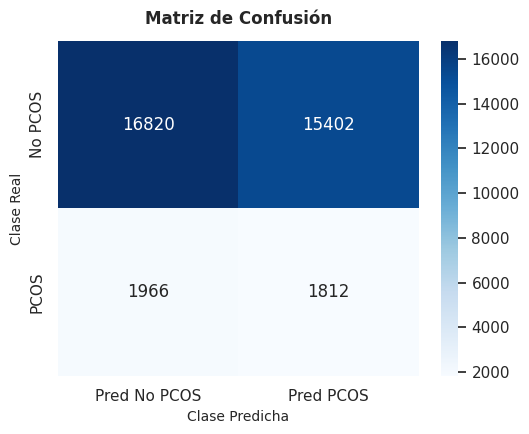

In [24]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5.5, 4.5))
# El formato "d" es para que muestre los números enteros completos sin decimales
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Pred No PCOS", "Pred PCOS"],
            yticklabels=["No PCOS", "PCOS"])

plt.title("Matriz de Confusión", fontsize=12, fontweight='bold', pad=12)
plt.ylabel("Clase Real", fontsize=10)
plt.xlabel("Clase Predicha", fontsize=10)
plt.tight_layout()
plt.show()

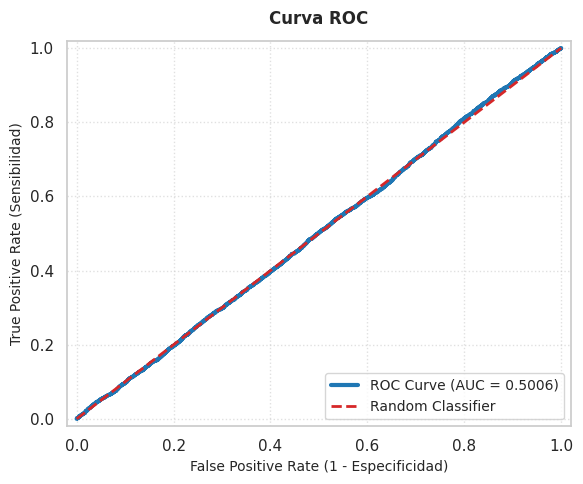

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(6, 5))
# Pintamos la curva del modelo en azul
plt.plot(fpr, tpr, color="#1f77b4", lw=3, label=f"ROC Curve (AUC = {auc:.4f})")
# Pintamos la línea diagonal segmentada del clasificador aleatorio en rojo
plt.plot([0, 1], [0, 1], color="#d62728", linestyle="--", lw=2, label="Random Classifier")

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)", fontsize=10)
plt.ylabel("True Positive Rate (Sensibilidad)", fontsize=10)
plt.title("Curva ROC", fontsize=12, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## Coeficientes

TABLA DE TOP 20 VARIABLES GLOBALES
                         Variable  Coeficiente  Importancia
             cat__BMI_Underweight     0.104756     0.104756
 cat__Socioeconomic Status_Middle     0.069588     0.069588
             cat__Ethnicity_Asian    -0.041368     0.041368
           cat__Stress Levels_Low     0.041260     0.041260
             cat__Ethnicity_Other    -0.031290     0.031290
      cat__Fertility Concerns_Yes    -0.029900     0.029900
                   cat__BMI_Obese     0.025475     0.025475
         cat__Ethnicity_Caucasian     0.018756     0.018756
           cat__Urban/Rural_Urban     0.017702     0.017702
                         num__Age     0.014976     0.014976
cat__Menstrual Regularity_Regular     0.014823     0.014823
       cat__Awareness of PCOS_Yes    -0.014224     0.014224
  cat__Family History of PCOS_Yes    -0.013468     0.013468
      cat__Insulin Resistance_Yes     0.013426     0.013426
               cat__Hirsutism_Yes     0.011881     0.011881
     

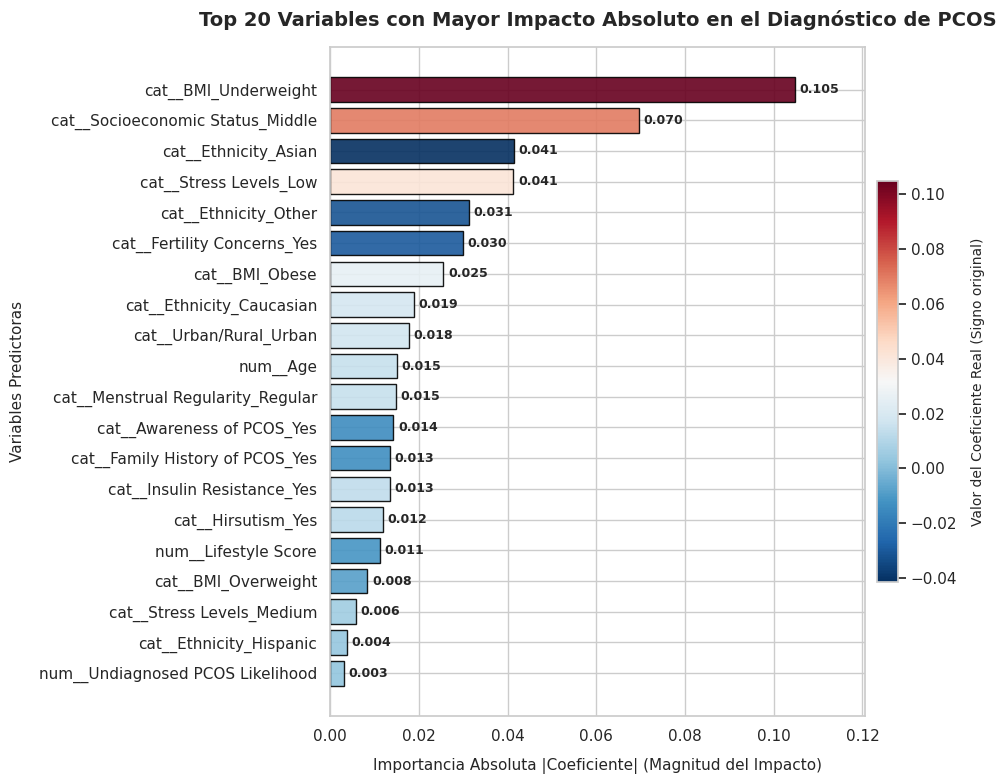

In [12]:
# Aseguramos el renderizado estático en el cuaderno
%matplotlib inline

# 1. EXTRACCIÓN DE NOMBRES DE VARIABLES
feature_names = (
    pipeline_logit.named_steps["preprocessing"]
    .get_feature_names_out()
)

# 2. EXTRACCIÓN DE COEFICIENTES
coeficients = (
    pipeline_logit.named_steps["model"]
    .coef_[0]
)

# Creación del DataFrame calculando el valor absoluto de la importancia
importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficients,
    "Importancia": np.abs(coeficients)
})

# Ordenamos de mayor a menor magnitud absoluta
importance_df = importance_df.sort_values(by="Importancia", ascending=False)

# Tomamos el Top 20 global
top_importance = importance_df.head(20)

# Imprimimos la tabla en texto plano como pide el script original
print("="*35)
print("TABLA DE TOP 20 VARIABLES GLOBALES")
print("="*35)
print(top_importance.to_string(index=False))
print("\n")

# =================================================== #
#     GRÁFICA HORIZONTAL CON MATPLOTLIB Y SEABORN     #
# =================================================== #
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Ordenamos de menor a mayor importancia absoluta para que la barra más larga quede arriba
top_importance = top_importance.sort_values(by="Importancia", ascending=True)

# Mapeamos los colores usando una paleta Divergente (Red-Blue) basada en el Coeficiente Real
# Los coeficientes muy positivos tenderán a rojo y los muy negativos a azul
norm = plt.Normalize(top_importance["Coeficiente"].min(), top_importance["Coeficiente"].max())
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
colors = [sm.to_rgba(c) for c in top_importance["Coeficiente"]]

# Dibujamos las barras horizontales
bars = plt.barh(
    top_importance["Variable"], 
    top_importance["Importancia"], 
    color=colors,
    edgecolor="black",
    alpha=0.9
)

# Añadimos los valores de magnitud de la importancia sobre el final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max(top_importance["Importancia"]) * 0.01), # Espaciado dinámico a la derecha
        bar.get_y() + bar.get_height()/2, 
        f'{width:.3f}', 
        va='center', 
        ha='left', 
        fontsize=9, 
        fontweight='bold'
    )

# Añadimos la barra de color (Colorbar) para que se entienda el gradiente de los coeficientes
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02, shrink=0.6)
cbar.set_label("Valor del Coeficiente Real (Signo original)", fontsize=10, labelpad=10)

# Títulos y nombres de ejes adaptados formalmente a PCOS
plt.title("Top 20 Variables con Mayor Impacto Absoluto en el Diagnóstico de PCOS", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Importancia Absoluta |Coeficiente| (Magnitud del Impacto)", fontsize=11, labelpad=10)
plt.ylabel("Variables Predictoras", fontsize=11, labelpad=10)

# Ajustamos límites de visibilidad para el texto
plt.xlim(0, max(top_importance["Importancia"]) * 1.15)

plt.tight_layout()
plt.show()

## Guardado del modelo

In [26]:
import joblib

modelo_final = RandomizedSearchCV(
    estimator=pipeline_logit,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=123,
    n_jobs=-1
)

modelo_final.fit(X, y)

path_model = Path("../models/clasificacion_reg_logistica.joblib")

joblib.dump(modelo_final, path_model)
joblib.dump(X.columns.tolist(), Path("../models/feature_names_clasificacion.joblib"))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


['../models/feature_names_clasificacion.joblib']

# Arboles

In [13]:
preprocessor_tree = ColumnTransformer(
    [("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), var_cat)],
    remainder="passthrough",
)

In [14]:
models = {
    "tree": DecisionTreeClassifier(
        random_state=123, 
        #class_weight="balanced"
    ),
    "rnd_forest": RandomForestClassifier(
        random_state=123, 
        oob_score=True, 
        #class_weight="balanced"
    ),
    "xgb_boost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        #scale_pos_weight=np.sum(y_train == 0) / np.sum(y_train == 1),  # Balanceo para XGBoost
        random_state=123,
        eval_metric="logloss"
    )
}

In [15]:
from joblib import Parallel, delayed
from sklearn.base import clone
from sklearn.metrics import make_scorer

X_cv, y_cv = X_train, y_train 

metric_labels = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-Score",
    "roc_auc": "ROC-AUC",
}

tree_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}


def _clone_model_for_parallel(model):
    model_clone = clone(model)
    if "n_jobs" in model_clone.get_params():
        model_clone.set_params(n_jobs=1)
    return model_clone


def train_and_evaluate_tree_model(model_name, model):
    pipeline = ImbPipeline(
        steps=[
            ("preprocessing", clone(preprocessor_tree)),
            ("oversampling", clone(oversampler)),
            ("model", _clone_model_for_parallel(model)),
        ]
    )

    cv = InstanceHardnessCV(
        estimator=clone(pipeline),
        n_splits=5,
    )

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_cv,
        y=y_cv,
        cv=cv,
        scoring=tree_scoring,
        return_train_score=False,
        n_jobs=1,
        error_score="raise",
    )

    row = {"Modelo": model_name}
    for metric, label in metric_labels.items():
        scores = cv_results[f"test_{metric}"]
        row[label] = scores.mean()
        row[f"{label} std"] = scores.std()

    fitted_pipeline = ImbPipeline(
        steps=[
            ("preprocessing", clone(preprocessor_tree)),
            ("oversampling", clone(oversampler)),
            ("model", _clone_model_for_parallel(model)),
        ]
    )
    fitted_pipeline.fit(X_train, y_train)

    return model_name, row, fitted_pipeline


parallel_results = Parallel(n_jobs=-1)(
    delayed(train_and_evaluate_tree_model)(model_name, model)
    for model_name, model in models.items()
)

fitted_tree_models = {
    model_name: fitted_pipeline
    for model_name, _, fitted_pipeline in parallel_results
}

tree_metrics_df = (
    pd.DataFrame([row for _, row, _ in parallel_results])
    .set_index("Modelo")
    .sort_values("ROC-AUC", ascending=False)
    .round(4)
)

tree_metrics_df

,Accuracy,Accuracy std,Precision,Precision std,Recall,Recall std,F1-Score,F1-Score std,ROC-AUC,ROC-AUC std
Modelo,,,,,,,,,,
xgb_boost,0.5330,0.0057,0.1044,0.0018,0.4553,0.0039,0.1699,0.0025,0.5000,0.0058
tree,0.8094,0.0036,0.1048,0.0096,0.1081,0.0095,0.1064,0.0094,0.4999,0.0055
rnd_forest,0.8908,0.0003,0.1145,0.0245,0.0060,0.0016,0.0114,0.0031,0.4993,0.0029


## Hiperparámetros XGBoost


In [16]:
from sklearn.base import clone
from sklearn.metrics import make_scorer

xgb_base_model = clone(models["xgb_boost"])
if "n_jobs" in xgb_base_model.get_params():
    xgb_base_model.set_params(n_jobs=1)

xgb_pipeline = ImbPipeline(
    steps=[
        ("preprocessing", clone(preprocessor_tree)),
        ("oversampling", oversampler),
        (
            "model",
            XGBClassifier(
                #scale_pos_weight=np.sum(y_train == 0) / np.sum(y_train == 1),
                random_state=123,
                eval_metric="logloss"
            ),
        ),
    ]
)

xgb_param_dist = {
    "model__n_estimators": randint(100, 600),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.20),
    "model__subsample": uniform(0.60, 0.40),
    "model__colsample_bytree": uniform(0.60, 0.40),
    "model__min_child_weight": randint(1, 8),
    "model__gamma": uniform(0, 3),
    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0.5, 2.5),
}

xgb_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

xgb_cv = InstanceHardnessCV(
    estimator=clone(xgb_pipeline),
    n_splits=5,
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=50,
    scoring=xgb_scoring,
    refit="roc_auc",
    cv=xgb_cv,
    verbose=1,
    random_state=123,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise",
)

xgb_random_search.fit(X_train, y_train)

xgb_best_model = xgb_random_search.best_estimator_
xgb_best_index = xgb_random_search.best_index_

xgb_y_pred_best = xgb_best_model.predict(X_test)
xgb_y_prob_best = xgb_best_model.predict_proba(X_test)[:, 1]

xgb_best_metrics = pd.DataFrame(
    {
        "Métrica": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC",
        ],
        "Valor test": [
            accuracy_score(y_test, xgb_y_pred_best),
            precision_score(y_test, xgb_y_pred_best, zero_division=0),
            recall_score(y_test, xgb_y_pred_best, zero_division=0),
            f1_score(y_test, xgb_y_pred_best, zero_division=0),
            roc_auc_score(y_test, xgb_y_prob_best),
        ],
        "Promedio CV": [
            xgb_random_search.cv_results_["mean_test_accuracy"][xgb_best_index],
            xgb_random_search.cv_results_["mean_test_precision"][xgb_best_index],
            xgb_random_search.cv_results_["mean_test_recall"][xgb_best_index],
            xgb_random_search.cv_results_["mean_test_f1"][xgb_best_index],
            xgb_random_search.cv_results_["mean_test_roc_auc"][xgb_best_index],
        ],
        "Desv. Std CV": [
            xgb_random_search.cv_results_["std_test_accuracy"][xgb_best_index],
            xgb_random_search.cv_results_["std_test_precision"][xgb_best_index],
            xgb_random_search.cv_results_["std_test_recall"][xgb_best_index],
            xgb_random_search.cv_results_["std_test_f1"][xgb_best_index],
            xgb_random_search.cv_results_["std_test_roc_auc"][xgb_best_index],
        ],
    }
).round(4)

print("\n" + "=" * 34)
print("MEJORES HIPERPARÁMETROS XGB_BOOST")
print("=" * 34)
print(xgb_random_search.best_params_)
print(f"\nMejor ROC-AUC promedio CV: {xgb_random_search.best_score_:.4f}")
xgb_best_metrics

Fitting 5 folds for each of 50 candidates, totalling 250 fits

MEJORES HIPERPARÁMETROS XGB_BOOST
{'model__colsample_bytree': np.float64(0.7984785146611924), 'model__gamma': np.float64(0.5170278828628136), 'model__learning_rate': np.float64(0.1467978392815552), 'model__max_depth': 9, 'model__min_child_weight': 2, 'model__n_estimators': 228, 'model__reg_alpha': np.float64(0.463652724885516), 'model__reg_lambda': np.float64(1.7555408383069677), 'model__subsample': np.float64(0.725467580020851)}

Mejor ROC-AUC promedio CV: 0.5144


,Métrica,Valor test,Promedio CV,Desv. Std CV
0,Accuracy,0.8008,0.8105,0.0014
1,Precision,0.1042,0.1083,0.0052
2,Recall,0.1183,0.1114,0.0056
3,F1-Score,0.1108,0.1098,0.0053
4,ROC-AUC,0.4995,0.5144,0.0047


## Matriz de confusión y curva ROC - XGBoost


REPORTE DE CLASIFICACIÓN XGB_BOOST
              precision    recall  f1-score   support

     No PCOS       0.89      0.88      0.89     32222
        PCOS       0.10      0.12      0.11      3778

    accuracy                           0.80     36000
   macro avg       0.50      0.50      0.50     36000
weighted avg       0.81      0.80      0.81     36000



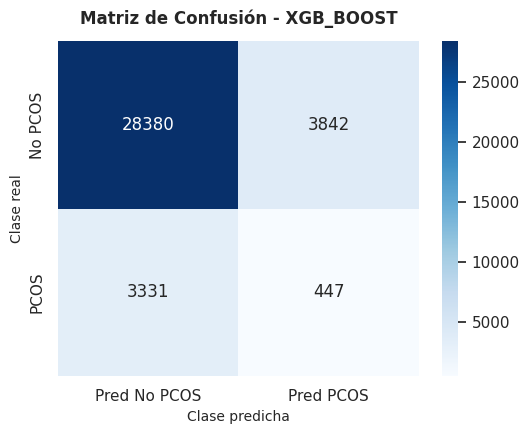

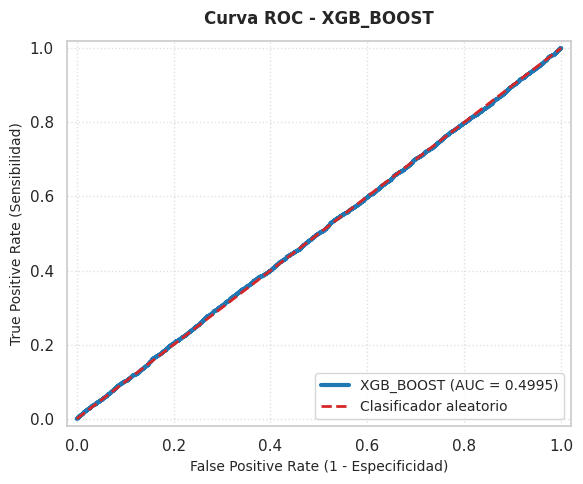

In [17]:
xgb_y_pred_best = xgb_best_model.predict(X_test)
xgb_y_prob_best = xgb_best_model.predict_proba(X_test)[:, 1]

xgb_cm = confusion_matrix(y_test, xgb_y_pred_best, labels=[0, 1])
xgb_auc = roc_auc_score(y_test, xgb_y_prob_best)
xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(y_test, xgb_y_prob_best)

print("\n" + "=" * 38)
print("REPORTE DE CLASIFICACIÓN XGB_BOOST")
print("=" * 38)
print(
    classification_report(
        y_test,
        xgb_y_pred_best,
        labels=[0, 1],
        target_names=["No PCOS", "PCOS"],
        zero_division=0,
    )
)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred No PCOS", "Pred PCOS"],
    yticklabels=["No PCOS", "PCOS"],
)
plt.title("Matriz de Confusión - XGB_BOOST", fontsize=12, fontweight="bold", pad=12)
plt.ylabel("Clase real", fontsize=10)
plt.xlabel("Clase predicha", fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(
    xgb_fpr,
    xgb_tpr,
    color="#1f77b4",
    lw=3,
    label=f"XGB_BOOST (AUC = {xgb_auc:.4f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    color="#d62728",
    linestyle="--",
    lw=2,
    label="Clasificador aleatorio",
)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)", fontsize=10)
plt.ylabel("True Positive Rate (Sensibilidad)", fontsize=10)
plt.title("Curva ROC - XGB_BOOST", fontsize=12, fontweight="bold", pad=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## Importancia de variables - XGBoost

TOP 20 VARIABLES MÁS IMPORTANTES XGB_BOOST
                              Variable  Importancia
remainder__Undiagnosed PCOS Likelihood       0.0552
                        remainder__Age       0.0514
                  cat__BMI_Underweight       0.0498
                   cat__BMI_Overweight       0.0489
                    cat__Hirsutism_Yes       0.0484
                        cat__BMI_Obese       0.0484
              cat__Ethnicity_Caucasian       0.0483
           cat__Fertility Concerns_Yes       0.0481
            remainder__Lifestyle Score       0.0475
             cat__Stress Levels_Medium       0.0472
     cat__Menstrual Regularity_Regular       0.0468
               cat__Ethnicity_Hispanic       0.0467
       cat__Family History of PCOS_Yes       0.0467
      cat__Socioeconomic Status_Middle       0.0467
           cat__Insulin Resistance_Yes       0.0466
         cat__Socioeconomic Status_Low       0.0465
                  cat__Ethnicity_Asian       0.0464
                  cat

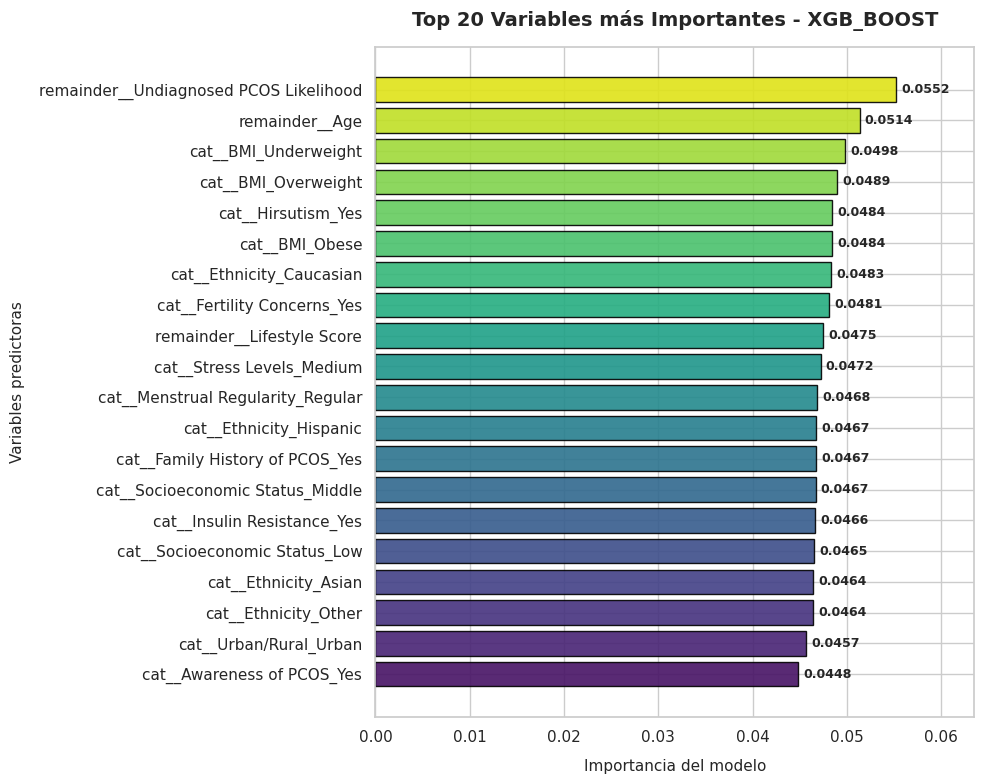

In [18]:
xgb_feature_names = (
    xgb_best_model.named_steps["preprocessing"]
    .get_feature_names_out()
)

xgb_importances = (
    xgb_best_model.named_steps["model"]
    .feature_importances_
)

xgb_importance_df = pd.DataFrame(
    {
        "Variable": xgb_feature_names,
        "Importancia": xgb_importances,
    }
).sort_values(by="Importancia", ascending=False)

top_n = 20
xgb_top_importance = xgb_importance_df.head(top_n)

print("=" * 45)
print(f"TOP {top_n} VARIABLES MÁS IMPORTANTES XGB_BOOST")
print("=" * 45)
print(xgb_top_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

xgb_top_importance_plot = xgb_top_importance.sort_values(
    by="Importancia",
    ascending=True,
)

bars = plt.barh(
    xgb_top_importance_plot["Variable"],
    xgb_top_importance_plot["Importancia"],
    color=sns.color_palette("viridis", n_colors=len(xgb_top_importance_plot)),
    edgecolor="black",
    alpha=0.9,
)

max_importance = xgb_top_importance_plot["Importancia"].max()
text_offset = max_importance * 0.01 if max_importance > 0 else 0.001

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + text_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
    )

plt.title("Top 20 Variables más Importantes - XGB_BOOST", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Importancia del modelo", fontsize=11, labelpad=10)
plt.ylabel("Variables predictoras", fontsize=11, labelpad=10)
plt.xlim(0, max_importance * 1.15 if max_importance > 0 else 1)
plt.tight_layout()
plt.show()

# Balanceo

In [19]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf_model = ImbPipeline(
    steps=[
        ("preprocessor", clone(preprocessor_tree)),
        (
            "model",
            BalancedRandomForestClassifier(
                random_state=123,
            ),
        ),
    ]
)

cv = InstanceHardnessCV(
    estimator=clone(brf_model),
    n_splits=5,
)

scores = cross_validate(
    estimator=brf_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=tree_scoring,
    return_train_score=False,
    n_jobs=-1,
    error_score="raise",
)

results_df = pd.DataFrame(
    [
        {
            "Accuracy": np.mean(scores["test_accuracy"]),
            "Precision": np.mean(scores["test_precision"]),
            "Recall": np.mean(scores["test_recall"]),
            "F1": np.mean(scores["test_f1"]),
            "ROC_AUC": np.mean(scores["test_roc_auc"]),
        }
    ]
)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)